# IMPORT LIBRARIES AND DATASET

In [36]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score , classification_report , confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.model_selection import GridSearchCV

import warnings 
warnings.filterwarnings('ignore')

In [7]:
df = pd.read_csv('data_sets/processed/Prepared.csv')
df = df.astype('int')
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_group_Mid,tenure_group_Loyal,MonthlyCharges_group_Medium,MonthlyCharges_group_High
0,0,0,1,0,1,0,1,29,29,0,...,0,0,0,0,1,0,0,0,0,0
1,1,0,0,0,34,1,0,56,1889,0,...,0,1,0,0,0,1,1,0,1,0
2,1,0,0,0,2,1,1,53,108,1,...,0,0,0,0,0,1,0,0,1,0
3,1,0,0,0,45,0,0,42,1840,0,...,0,1,0,0,0,0,0,1,1,0
4,0,0,0,0,2,1,1,70,151,1,...,0,0,0,0,1,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,1,0,1,1,24,1,1,84,1990,0,...,1,1,0,0,0,1,1,0,0,1
7028,0,0,1,1,72,1,1,103,7362,0,...,1,1,0,1,0,0,0,1,0,1
7029,0,0,1,1,11,0,1,29,346,0,...,0,0,0,0,1,0,0,0,0,0
7030,1,1,1,0,4,1,1,74,306,1,...,0,0,0,0,0,1,0,0,0,1


# SPLIT THE DATASET IN TRAIN AND TEST

In [8]:
x = df.drop(columns=['Churn'])
y = df['Churn']

In [12]:
x_train , x_test , y_train , y_test = train_test_split(x, y, test_size=0.2 , random_state=42)

data = [x_train , x_test , y_train , y_test]

for i in data:
    print(i.shape)

(5625, 31)
(1407, 31)
(5625,)
(1407,)


# MODEL 1
logistic regression

In [15]:
lr = LogisticRegression(max_iter=1000)
lr.fit(x_train,y_train)

y_pred_lr = lr.predict(x_test)

print('LogisticRegression accuracy : ', accuracy_score(y_test , y_pred_lr))
print(classification_report(y_test , y_pred_lr))

LogisticRegression accuracy :  0.7896233120113717
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.64      0.48      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407



# MODEL 2
RandomForestClassifer

In [16]:
rf = RandomForestClassifier()
rf.fit(x_train, y_train)

y_pred_rf = rf.predict(x_test)

print('RandomForestClassifier accuracy : ', accuracy_score(y_test , y_pred_rf))
print(classification_report(y_test , y_pred_rf))

RandomForestClassifier accuracy :  0.7896233120113717
              precision    recall  f1-score   support

           0       0.82      0.91      0.86      1033
           1       0.65      0.46      0.54       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.78      0.79      0.78      1407



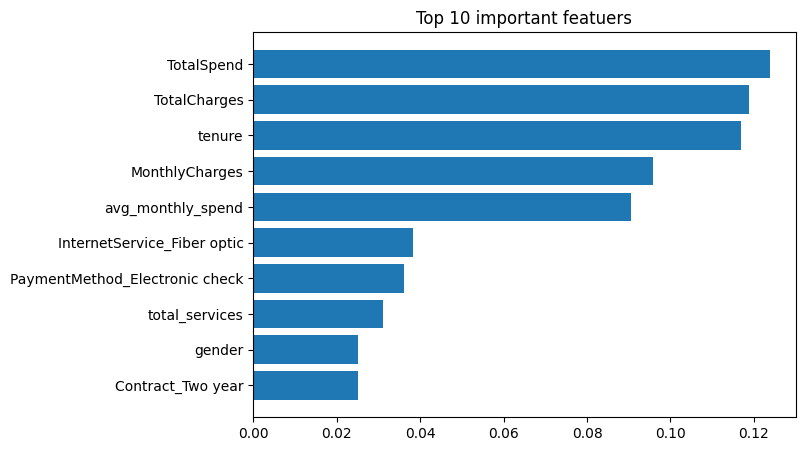

In [32]:
# feature importance according randomforest
importance= rf.feature_importances_
featuers = x.columns

feat_df = pd.DataFrame({'Featuers' : featuers,
                        'Importance' : importance})
feat_df = feat_df.sort_values(by = 'Importance' , ascending=False)

plt.figure(figsize=(7,5))
plt.barh(feat_df['Featuers'][:10] , feat_df['Importance'][:10])
plt.gca().invert_yaxis()
plt.title('Top 10 important featuers')
plt.show()

# MODEL 3
GradientBoostingClassifier

In [17]:
gb = GradientBoostingClassifier()
gb.fit(x_train , y_train)

y_pred_gb = gb.predict(x_test)

print(' GradientBoostingClassifier Accuracy : ', accuracy_score(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb))

 GradientBoostingClassifier Accuracy :  0.7924662402274343
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.64      0.49      0.56       374

    accuracy                           0.79      1407
   macro avg       0.74      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



# MODEL COMPARISION

In [21]:
results = {
    "Logistic Regression": accuracy_score(y_test, y_pred_lr),
    "Random Forest": accuracy_score(y_test, y_pred_rf),
    "Gradient Boosting": accuracy_score(y_test, y_pred_gb)
}

print(results)

{'Logistic Regression': 0.7896233120113717, 'Random Forest': 0.7896233120113717, 'Gradient Boosting': 0.7924662402274343}


Although Gradient Boosting performed slightly better, Logistic Regression also achieved comparable performance, indicating that the dataset has relatively linear separability.


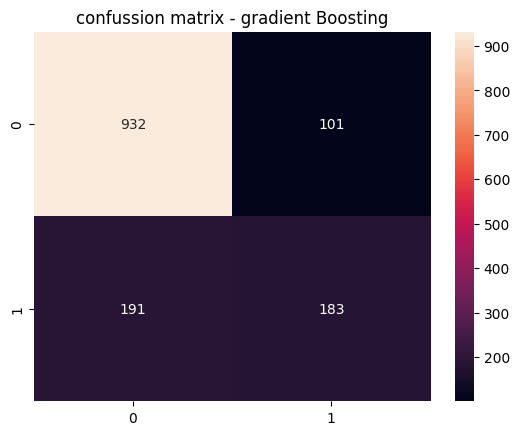

In [35]:
cm = confusion_matrix(y_test , y_pred_gb)

sns.heatmap(cm, annot=True , fmt='d')
plt.title('confussion matrix - gradient Boosting')
plt.show()

# Hyperparameter Tuning

In [39]:
params = {
    'n_estimators': [100,200],
    'learning_rate': [0.01,0.05,0.1],
    'max_depth': [3,5]
}

gb_grid = GridSearchCV(
    GradientBoostingClassifier(),
    param_grid=params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

gb_grid.fit(x_train,y_train)

print('best params',gb_grid.best_params_)
print('best score',gb_grid.best_score_)

best params {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
best score 0.8060444444444445


# FEATUER SELECTION

In [45]:
top_featuers = feat_df['Featuers'][:15]

x_top = x[top_featuers]

In [47]:
x_train_top, x_test_top, y_train, y_test = train_test_split(
    x_top, y, test_size=0.2, random_state=42
)

gb.fit(x_train_top, y_train)
y_pred_top = gb.predict(x_test_top)

print("Accuracy with top features:", accuracy_score(y_test, y_pred_top))

Accuracy with top features: 0.7931769722814499


Hyperparameter tuning and feature selection resulted in marginal improvements, indicating that the dataset is relatively simple and the base model was already performing near optimal. This suggests that the key predictive power lies in the data itself rather than model complexity.

Multiple models were evaluated, including Logistic Regression, Random Forest, and Gradient Boosting. While Gradient Boosting achieved the highest accuracy (~80%), Logistic Regression performed comparably, indicating that the dataset has relatively linear patterns. Hyperparameter tuning and feature selection resulted in marginal improvements, suggesting that the base model was already near optimal performance.